# Dual Optimal Contractive Halpern (Dual-OC-Halpern)

This notebook applies the Lyapunov discovery procedure to Dual-OC-Halpern for a maximally $\mu$-strongly monotone operator $A$. Set $\gamma=1+2\mu$ and $\varphi_k=\sum_{i=0}^k\gamma^{2i}$. The method is
$$
\begin{aligned}
    x_{k+1} &= J_A y_k, \\
    T y_k &= \left(1+\frac{1}{\gamma}\right)x_{k+1}-\frac{1}{\gamma}y_k, \\
    y_{k+1} &= y_k+\left(1-\frac{1}{\varphi_{N-k-1}}\right)(T y_k-T y_{k-1}),
\end{aligned}
$$
with $T y_{-1}=y_0$ and $A x_k=y_{k-1}-x_k$. The target guarantee is
$$
    \|A x_N\|^2\le \frac{\|y_0-x_\star\|^2}{\left(\sum_{i=0}^{N-1}\gamma^i\right)^2}.
$$

## Import the required libraries

In [1]:
import pepflow as pf
import pepflow.lyapunov_utils as lu
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
import functools
import itertools
from IPython.display import display
import IPython.display as ipd

## Define the operators

In [2]:
mu = pf.Parameter(r"\mu")
A = pf.StronglyMonotoneOperator(is_basis=True, tags=["A"], mu=mu)

## Write a function that generates a PEPContext object associated with Dual-OC-Halpern

In [3]:
@functools.cache
def beta_reciprocal(k, mu_value):
    if k == -1:
        return sp.S(0)
    return beta_reciprocal(k - 1, mu_value) + (sp.S(1) + 2 * mu_value) ** (2 * k)


@functools.cache
def gamma_geometric_sum(N, mu_value):
    if N == -1:
        return sp.S(0)
    return gamma_geometric_sum(N - 1, mu_value) + (sp.S(1) + 2 * mu_value) ** N

In [4]:
def make_ctx_dual_oc_halpern(ctx_name: str, N: int | sp.Integer) -> pf.PEPContext:
    ctx_dual_oc = pf.PEPContext(ctx_name).set_as_current()
    beta = [pf.Parameter(f"beta_{i}") for i in range(N)]

    A.set_zero_point("x_star")
    y = pf.Vector(is_basis=True, tags=["y_0"])
    Ty_prev = y

    for i in range(N):
        x = A.resolvent(y, sp.S(1), tag=f"x_{i + 1}")
        Ty = (
            (sp.S(1) + 1 / (sp.S(1) + 2 * mu)) * x - 1 / (sp.S(1) + 2 * mu) * y
        ).add_tag(f"Ty_{i}")
        y = (y + (1 - beta[i]) * (Ty - Ty_prev)).add_tag(f"y_{i + 1}")
        Ty_prev = Ty

    return ctx_dual_oc

## Numerical evidence showing that Dual-OC-Halpern converges at the rate $\|A x_N\|^2 \le \frac{\|y_0-x_\star\|^2}{(\sum_{i=0}^{N-1}\gamma^i)^2}$

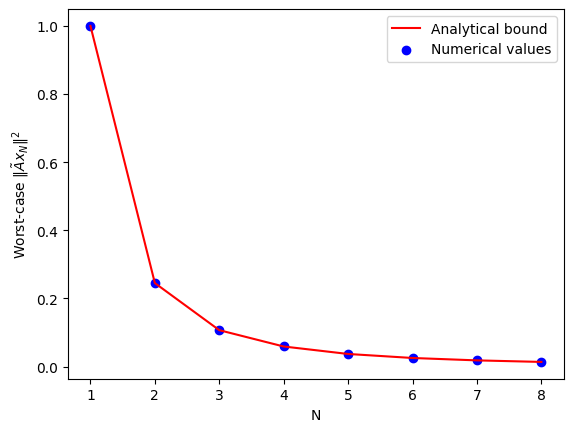

In [5]:
N_max = 8
R = pf.Parameter("R")
R_value = 1
mu_value = sp.Rational(1, 100)

opt_values = []
for N in range(1, N_max + 1):
    resolve_par_num = {
        f"beta_{i}": 1 / beta_reciprocal(N - i - 1, mu_value) for i in range(N)
    }
    resolve_par_num |= {"R": R_value, r"\mu": mu_value}

    ctx_N = make_ctx_dual_oc_halpern(ctx_name=f"ctx_{N}", N=N)
    pb_plt = pf.PEPBuilder(ctx_N)
    pb_plt.add_initial_constraint(
        ((ctx_N["y_0"] - ctx_N["x_star"]) ** 2).le(R, name="initial_condition")
    )
    pb_plt.set_performance_metric(A(ctx_N[f"x_{N}"]) ** 2)
    result = pb_plt.solve(resolve_parameters=resolve_par_num)
    opt_values.append(result.opt_value)

iters = np.arange(1, N_max + 1)
bound_vals = np.array(
    [1 / gamma_geometric_sum(int(N - 1), mu_value) ** 2 for N in iters], dtype=float
)
plt.plot(iters, bound_vals, "r-", label="Analytical bound")
plt.scatter(iters, opt_values, color="blue", marker="o", label="Numerical values")
plt.xlabel("N")
plt.ylabel(r"Worst-case $\|\tilde{A} x_N\|^2$")
plt.legend()

## Verification of convergence of Dual-OC-Halpern

In [6]:
N = sp.S(6)
R_value = sp.S(1)
mu_value = sp.Rational(1, 100)
expected_rate = sp.S(1) / gamma_geometric_sum(N - 1, mu_value) ** 2

resolve_par_num = {
    f"beta_{i}": 1 / beta_reciprocal(N - i - 1, mu_value) for i in range(N)
}
resolve_par_num |= {"R": R_value, r"\mu": mu_value}

ctx_prf = make_ctx_dual_oc_halpern(ctx_name="ctx_prf", N=N)
pb_prf = pf.PEPBuilder(ctx_prf)
pb_prf.add_initial_constraint(
    ((ctx_prf["y_0"] - ctx_prf["x_star"]) ** 2).le(R, name="initial_condition")
)
pb_prf.set_performance_metric(A(ctx_prf[f"x_{N}"]) ** 2)

result = pb_prf.solve(resolve_parameters=resolve_par_num)
print(result.opt_value)
print("expected:", sp.N(expected_rate))

0.02512753857732292
expected: 0.0251304331765358


### No relaxation of the dual variables is needed, so we store the solver output

In [7]:
tau_sol = result.dual_var_manager.dual_value("initial_condition")
lamb_sol = result.get_scalar_constraint_dual_value_in_numpy(A)
S_sol = result.get_gram_dual_matrix()

In [8]:
lamb_sol.pprint()

<IPython.core.display.Math object>

In [9]:
S_sol.pprint()

<IPython.core.display.Math object>

### The Gram dual matrix has rank 1

In [10]:
np.linalg.matrix_rank(S_sol.matrix)

np.int64(1)

---

## Step 1. Propose a candidate Lyapunov function

### Choose $\mathcal{I}_k=\{(N,j):j=1,\dots,k\}, \,\, \mathcal{I}_0=\emptyset, \,\, \mathcal{J}_k=\emptyset$

In [11]:
def tag_to_index(tag, N=N):
    idx = tag.split("_", 1)[1]
    if idx.isdigit():
        return int(idx)
    if idx == "star":
        return N + 1
    raise ValueError(f"Unknown point tag: {tag}")

In [12]:
lyap = [pf.Scalar.zero()]
partial_sum = pf.Scalar.zero()
for j in np.arange(1, N):
    partial_sum += lamb_sol(f"x_{j}", f"x_{N}") * A.strongly_monotone_ineq(
        f"x_{j}", f"x_{N}"
    )
    lyap.append(partial_sum)

## Step 2. Check for admissibility

### Sufficiency is immediate. The remaining proof terms are the terminal strong-monotonicity inequality and one square term.

In [13]:
pm = pf.ExpressionManager(ctx_prf, resolve_parameters=resolve_par_num)

for k in range(len(lyap)):
    lyap_numeric_k = pm.eval_scalar(lyap[k]).inner_prod_coords.astype(float)
    print(f"Rank of lyap[{k}]: {np.linalg.matrix_rank(lyap_numeric_k, tol=1e-5)}")

Rank of lyap[0]: 0
Rank of lyap[1]: 2
Rank of lyap[2]: 4
Rank of lyap[3]: 4
Rank of lyap[4]: 4
Rank of lyap[5]: 2


## Step 3. Build a set of special candidate vectors

In [14]:
special_vectors = ctx_prf.basis_vectors()
y_0 = ctx_prf["y_0"]
x = [ctx_prf[f"x_{i}"] for i in range(1, N + 1)]
y = [ctx_prf[f"y_{i}"] for i in range(1, N)]
special_vectors += x + y
for i in range(1, N + 1):
    special_vectors.append(ctx_prf[f"Ty_{i - 1}"])

base_count = len(special_vectors)
for i, j in itertools.combinations(range(base_count), 2):
    diff = special_vectors[i] - special_vectors[j]
    diff.add_tag(f"{special_vectors[i].tag}-{special_vectors[j].tag}")
    special_vectors.append(diff)

In [15]:
print(special_vectors)

[x_star, y_0, A(x_1), A(x_2), A(x_3), A(x_4), A(x_5), A(x_6), x_1, x_2, x_3, x_4, x_5, x_6, y_1, y_2, y_3, y_4, y_5, Ty_0, Ty_1, Ty_2, Ty_3, Ty_4, Ty_5, x_star-y_0, x_star-A(x_1), x_star-A(x_2), x_star-A(x_3), x_star-A(x_4), x_star-A(x_5), x_star-A(x_6), x_star-x_1, x_star-x_2, x_star-x_3, x_star-x_4, x_star-x_5, x_star-x_6, x_star-y_1, x_star-y_2, x_star-y_3, x_star-y_4, x_star-y_5, x_star-Ty_0, x_star-Ty_1, x_star-Ty_2, x_star-Ty_3, x_star-Ty_4, x_star-Ty_5, y_0-A(x_1), y_0-A(x_2), y_0-A(x_3), y_0-A(x_4), y_0-A(x_5), y_0-A(x_6), y_0-x_1, y_0-x_2, y_0-x_3, y_0-x_4, y_0-x_5, y_0-x_6, y_0-y_1, y_0-y_2, y_0-y_3, y_0-y_4, y_0-y_5, y_0-Ty_0, y_0-Ty_1, y_0-Ty_2, y_0-Ty_3, y_0-Ty_4, y_0-Ty_5, A(x_1)-A(x_2), A(x_1)-A(x_3), A(x_1)-A(x_4), A(x_1)-A(x_5), A(x_1)-A(x_6), A(x_1)-x_1, A(x_1)-x_2, A(x_1)-x_3, A(x_1)-x_4, A(x_1)-x_5, A(x_1)-x_6, A(x_1)-y_1, A(x_1)-y_2, A(x_1)-y_3, A(x_1)-y_4, A(x_1)-y_5, A(x_1)-Ty_0, A(x_1)-Ty_1, A(x_1)-Ty_2, A(x_1)-Ty_3, A(x_1)-Ty_4, A(x_1)-Ty_5, A(x_2)-A(x_3), A(x_

## Step 4. Find a basis of $\mathbf{V}_k$ within the candidate vectors

### Inspect the aligned vectors and then fix the persistent vectors $A x_N$ and $y_0-x_N$ to search for decomposition with sparsest coefficient matrix

In [16]:
aligned_vectors_by_k = {}
for k in range(len(lyap)):
    aligned_vectors_k = lu.vectors_in_column_space(
        lyap[k],
        special_vectors,
        pep_context=ctx_prf,
        resolve_parameters=resolve_par_num,
        rtol=1e-5,
        atol=1e-5,
    )
    aligned_vectors_by_k[k] = aligned_vectors_k
    print(f"V_{k}:")
    print(aligned_vectors_k)
    print()

V_0:
[]

V_1:
[y_0-y_5, A(x_1)-A(x_6), x_1-x_6, Ty_0-Ty_5]

V_2:
[A(x_1), A(x_2), A(x_6), y_0-x_1, y_0-x_2, y_0-x_6, y_0-y_1, y_0-y_2, y_0-y_5, y_0-Ty_0, y_0-Ty_1, y_0-Ty_5, A(x_1)-A(x_2), A(x_1)-A(x_6), A(x_2)-A(x_6), x_1-x_2, x_1-x_6, x_1-y_1, x_1-y_2, x_1-y_5, x_1-Ty_0, x_1-Ty_1, x_1-Ty_5, x_2-x_6, x_2-y_1, x_2-y_2, x_2-y_5, x_2-Ty_0, x_2-Ty_1, x_2-Ty_5, x_6-y_1, x_6-y_2, x_6-y_5, x_6-Ty_0, x_6-Ty_1, x_6-Ty_5, y_1-y_2, y_1-y_5, y_1-Ty_0, y_1-Ty_1, y_1-Ty_5, y_2-y_5, y_2-Ty_0, y_2-Ty_1, y_2-Ty_5, y_5-Ty_0, y_5-Ty_1, y_5-Ty_5, Ty_0-Ty_1, Ty_0-Ty_5, Ty_1-Ty_5]

V_3:
[A(x_6), y_0-x_6, y_0-y_3, y_0-y_5, y_0-Ty_2, y_0-Ty_5, x_6-y_3, x_6-y_5, x_6-Ty_2, x_6-Ty_5, y_3-y_5, y_3-Ty_2, y_3-Ty_5, y_5-Ty_2, y_5-Ty_5, Ty_2-Ty_5]

V_4:
[A(x_5), A(x_6), y_0-x_5, y_0-y_5, y_0-Ty_4, x_5-x_6, x_5-y_4, x_5-y_5, x_5-Ty_3, x_5-Ty_4, x_5-Ty_5, x_6-y_4, x_6-y_5, x_6-Ty_3, x_6-Ty_4, x_6-Ty_5, y_4-y_5, y_4-Ty_3, y_4-Ty_4, y_4-Ty_5, y_5-Ty_4, y_5-Ty_5, Ty_3-Ty_5]

V_5:
[A(x_6), x_6-y_5, x_6-Ty_5, y_5-Ty_5]



In [17]:
fixed_vectors = [ctx_prf[f"A(x_{N})"], y_0 - ctx_prf[f"x_{N}"]]
fixed_strings = {str(v) for v in fixed_vectors}

for k in range(2, len(lyap) - 1):
    aligned_vectors_k = [
        v for v in aligned_vectors_by_k[k] if str(v) not in fixed_strings
    ]
    aligned_vectors_k += fixed_vectors
    best_vectors, best_coefficients = lu.find_basis_with_sparsest_coefficients(
        lyap[k],
        aligned_vectors_k,
        pep_context=ctx_prf,
        resolve_parameters=resolve_par_num,
        fixed_vectors=fixed_vectors,
        zero_tol=1e-3,
        indep_tol=1e-3,
    )
    labels_k = [str(v) for v in best_vectors]
    print(f"V_{k}:")
    print("Sparsest basis:", best_vectors)
    pf.pprint_labeled_matrix(best_coefficients, labels_k, labels_k)
    print()

C:\Users\Jack\Documents\GitHub\PEPFlow_public\pepflow\lyapunov_utils.py:396: UserWarning:

Exhaustive subset search may be slow: checking 1225 subsets.



V_2:
Sparsest basis: [y_2-y_5, Ty_1-Ty_5, A(x_6), y_0-(x_6)]


<IPython.core.display.Math object>


V_3:
Sparsest basis: [y_3-y_5, Ty_2-Ty_5, A(x_6), y_0-(x_6)]


<IPython.core.display.Math object>


V_4:
Sparsest basis: [x_5-x_6, y_4-y_5, A(x_6), y_0-(x_6)]


<IPython.core.display.Math object>

### This suggests that $\{\tilde{A}x_N, y_0 - x_N, y_k - y_{N-1}, Ty_{k-1} - Ty_{N-1}\}$ is a basis.
### Assuming the coefficients for $\tilde{A}x_N, y_0 - x_N$ terms are constants (up to numerical error), we hypothesize a translated Lyapunov function
$$
    \widetilde V_k
    = a_k\|y_k-y_{N-1}\|^2
      + b \langle y_k-y_{N-1}, T y_{k-1}-T y_{N-1}\rangle
      + c_k\|T y_{k-1}-T y_{N-1}\|^2.
$$

In [18]:
def V_k_basis(k: int):
    return [
        ctx_prf[f"A(x_{N})"],
        y_0 - ctx_prf[f"x_{N}"],
        ctx_prf[f"y_{k}-y_{N - 1}"],
        ctx_prf[f"Ty_{k - 1}-Ty_{N - 1}"],
    ]


for k in range(2, len(lyap) - 1):
    labels_k = [str(v) for v in V_k_basis(k)]
    C_k = lu.find_symmetric_coefficient_matrix(
        lyap[k],
        V_k_basis(k),
        pep_context=ctx_prf,
        resolve_parameters=resolve_par_num,
    )
    print(f"V_{k}:")
    pf.pprint_labeled_matrix(C_k, labels_k, labels_k)
    print()

V_2:


<IPython.core.display.Math object>


V_3:


<IPython.core.display.Math object>


V_4:


<IPython.core.display.Math object>

---

## Step 5. Analytic proof

### Closed-form of $\lambda$ and $S$
### We have $\lambda_{k,N}=\frac{2(1+\gamma^{-N})}{1+\gamma}\,\frac{\gamma^{2(N-k)}}{\varphi_{N-k}\varphi_{N-k-1}}$ for $k=1,\dots,N-1$, and $\lambda_{N,\star}=2/\Gamma_N$, where $\Gamma_N=\sum_{i=0}^{N-1}\gamma^i$.
### Interestingly, $\lambda_{k,N} = \frac{4}{\Gamma_N^2} \frac{1}{\lambda_{N-k,N-k+1}^{\text{(OC-Halpern)}}}$ and $\lambda_{N,\star}$ is the same as OC-Halpern.

In [19]:
def lamb(tag_i, tag_j, N=N):
    i = tag_to_index(tag_i, N)
    j = tag_to_index(tag_j, N)
    gamma = sp.S(1) + sp.S(2) * mu_value

    if {i, j} == {int(N), int(N) + 1}:
        return sp.S(2) / gamma_geometric_sum(int(N) - 1, mu_value)

    if i == int(N) and 1 <= j < int(N):
        k = j
    elif j == int(N) and 1 <= i < int(N):
        k = i
    else:
        return sp.S(0)

    return (
        sp.S(2)
        * (sp.S(1) + gamma ** (-N))
        / (sp.S(1) + gamma)
        * gamma ** (sp.S(2) * (N - k))
        / (beta_reciprocal(N - k, mu_value) * beta_reciprocal(N - k - 1, mu_value))
    )


lamb_cand = pf.pprint_labeled_matrix(
    lamb, lamb_sol.row_names, lamb_sol.col_names, return_matrix=True
)
print(
    "Did we guess the right closed form of lambda?",
    np.allclose(lamb_cand, lamb_sol.matrix, atol=1e-3),
)

<IPython.core.display.Math object>

Did we guess the right closed form of lambda? False


In [20]:
x_0 = ctx_prf["y_0"]
x_N = ctx_prf[f"x_{N}"]
x_star = ctx_prf["x_star"]
gamma = sp.S(1) + sp.S(2) * mu_value
gamma_sum = gamma_geometric_sum(int(N) - 1, mu_value)

S_guess = (
    expected_rate
    * gamma ** (-N)
    * (gamma_sum * A(x_N) + (x_N - x_0) - gamma**N * (x_N - x_star)) ** 2
)

S_guess_eval = pm.eval_scalar(S_guess).matrix
pf.pprint_labeled_matrix(S_guess_eval, S_sol.row_names, S_sol.col_names)
print(
    "Did we guess the right closed form of S?",
    np.allclose(S_guess_eval, S_sol.matrix, atol=1e-3),
)

<IPython.core.display.Math object>

Did we guess the right closed form of S? True


### Set up the symbolic system for solving $\widetilde V_k - \widetilde V_{k+1} = \lambda_{k+1,N}\left(\langle \tilde A x_{k+1}-\tilde A x_N,x_{k+1}-x_N\rangle -\mu\|x_{k+1}-x_N\|^2 \right)$.
### Below, for simplicity, we divide the identity by the factor $C_N = \gamma^2(1+\gamma^{-N})/(1+\gamma)^2$ while solving and multiply it back at the end.

In [21]:
ctx_dual_oc_lyap = pf.PEPContext("dual_oc_halpern_lyap_finder").set_as_current()

y_k = pf.Vector(is_basis=True, tags=["y_k"])
Ty_km1 = pf.Vector(is_basis=True, tags=["Ty_{k-1}"])
y_Nm1 = pf.Vector(is_basis=True, tags=["y_{N-1}"])
Ax_kp1 = pf.Vector(is_basis=True, tags=["Ax_{k+1}"])
Ax_N = pf.Vector(is_basis=True, tags=["Ax_N"])

gamma_param = pf.Parameter("gamma")
N_param = pf.Parameter("N")
varphi_Nmk1 = pf.Parameter("varphi_{N-k-1}")

varphi_Nmk = sp.S(1) + gamma_param**2 * varphi_Nmk1
varphi_Nmk2 = (varphi_Nmk1 - sp.S(1)) / gamma_param**2
dual_scale = (
    gamma_param**2
    * (sp.S(1) + gamma_param ** (-N_param))
    / (sp.S(1) + gamma_param) ** 2
)
mu_param = (gamma_param - sp.S(1)) / sp.S(2)

Ty_Nm1 = y_Nm1 - (sp.S(1) + 1 / gamma_param) * Ax_N
Ty_k = y_k - (sp.S(1) + 1 / gamma_param) * Ax_kp1
y_kp1 = y_k + (sp.S(1) - 1 / varphi_Nmk1) * (Ty_k - Ty_km1)

r_k = y_k - y_Nm1
s_k = Ty_km1 - Ty_Nm1
r_kp1 = y_kp1 - y_Nm1
s_kp1 = Ty_k - Ty_Nm1

a_k = pf.Parameter("a_k")
a_kp1 = pf.Parameter("a_{k+1}")
b = pf.Parameter("b")
c_k = pf.Parameter("c_k")
c_kp1 = pf.Parameter("c_{k+1}")

V_k = a_k * r_k**2 + b * r_k * s_k + c_k * s_k**2
V_kp1 = a_kp1 * r_kp1**2 + b * r_kp1 * s_kp1 + c_kp1 * s_kp1**2

x_kp1 = y_k - Ax_kp1
x_N = y_Nm1 - Ax_N
strong_monotonicity_term = (Ax_kp1 - Ax_N) * (x_kp1 - x_N) - mu_param * (
    x_kp1 - x_N
) ** 2
lambda_kp1_N = (
    sp.S(2)
    * (sp.S(1) + gamma_param ** (-N_param))
    / (sp.S(1) + gamma_param)
    * (gamma_param**2 * varphi_Nmk1 - varphi_Nmk1 + sp.S(1))
    / (varphi_Nmk1 * (varphi_Nmk1 - sp.S(1)))
)
lambda_kp1_N_normalized = lambda_kp1_N / dual_scale

diff = V_k - V_kp1 - lambda_kp1_N_normalized * strong_monotonicity_term

### Solve the identity for Lyapunov coefficients while imposing that $b$ is constant

### The solution making the formulas for $a_k, c_k$ consistent with respect to $k$ satisfies $b=2$ and is unique

In [22]:
basis = ctx_dual_oc_lyap.basis_vectors()
row_index = [str(v) for v in basis]
row_index

a_k_sp, a_kp1_sp, b_sp, c_k_sp, c_kp1_sp = sp.symbols("a_k a_{k+1} b c_k c_{k+1}")
gamma_sp = sp.Symbol(r"\gamma")
N_sp = sp.Symbol("N")
varphi_sp = sp.Symbol(r"\varphi_{N-k-1}")

pm_lyap = pf.ExpressionManager(
    ctx_dual_oc_lyap,
    resolve_parameters={
        "a_k": a_k_sp,
        "a_{k+1}": a_kp1_sp,
        "b": b_sp,
        "c_k": c_k_sp,
        "c_{k+1}": c_kp1_sp,
        "gamma": gamma_sp,
        "N": N_sp,
        "varphi_{N-k-1}": varphi_sp,
    },
)
diff_matrix_array = pm_lyap.eval_scalar(diff).inner_prod_coords
diff_matrix = sp.Matrix(diff_matrix_array).applyfunc(
    lambda entry: sp.factor(sp.together(sp.nsimplify(entry)))
)
diff_matrix_pretty = diff_matrix.applyfunc(
    lambda entry: sp.factor(sp.cancel(sp.together(entry)))
)
pf.pprint_labeled_matrix(
    np.array(diff_matrix_pretty.tolist(), dtype=object),
    row_index,
    row_index,
    precision=None,
)

unknowns = (a_k_sp, a_kp1_sp, b_sp, c_k_sp, c_kp1_sp)
solution_set = sp.linsolve(list(diff_matrix), unknowns)
solution_tuple = next(iter(solution_set))
parametric_solution = {
    unknown: sp.factor(sp.cancel(sp.together(expression)))
    for unknown, expression in zip(unknowns, solution_tuple)
}

print("Parametric normalized solution:")
display(
    ipd.Math(
        r"\begin{aligned}"
        + r"\\".join(
            sp.latex(sp.Eq(unknown, parametric_solution[unknown]))
            for unknown in unknowns
        )
        + r"\end{aligned}"
    )
)

<IPython.core.display.Math object>

Parametric normalized solution:


<IPython.core.display.Math object>

In [23]:
c_kp1_from_b = sp.factor(
    sp.cancel(
        sp.together(sp.solve(sp.Eq(parametric_solution[b_sp], b_sp), c_kp1_sp)[0])
    )
)
print("Solving the b-equation for c_{k+1} gives")
display(ipd.Math(sp.latex(sp.Eq(c_kp1_sp, c_kp1_from_b))))

c_k_from_current_step = sp.factor(
    sp.cancel(sp.together(parametric_solution[c_k_sp].subs(c_kp1_sp, c_kp1_from_b)))
)

# \varphi_{N-k} = 1 + \gamma^2 \varphi_{N-k-1}
varphi_Nmk_sp = sp.S(1) + gamma_sp**2 * varphi_sp
c_k_from_previous_step = sp.factor(
    sp.cancel(sp.together(c_kp1_from_b.subs(varphi_sp, varphi_Nmk_sp)))
)

print("Consistency of c_k across adjacent steps requires")
display(
    ipd.Math(
        r"\begin{aligned}"
        + sp.latex(sp.Eq(c_k_sp, c_k_from_current_step))
        + r"\\"
        + sp.latex(sp.Eq(c_k_sp, c_k_from_previous_step))
        + r"\end{aligned}"
    )
)

b_candidates = sp.solve(sp.Eq(c_k_from_current_step, c_k_from_previous_step), b_sp)
selected_b = b_candidates[0]
print("Equating the two formulas, we obtain:")
display(ipd.Math(sp.latex(sp.Eq(b_sp, selected_b))))

selected_solution = {
    unknown: sp.factor(
        sp.cancel(
            sp.together(
                parametric_solution[unknown]
                .subs(c_kp1_sp, c_kp1_from_b)
                .subs(b_sp, selected_b)
            )
        )
    )
    for unknown in unknowns
}

closed_form_normalized = {
    a_k_sp: -varphi_Nmk_sp / (varphi_Nmk_sp - sp.S(1)),
    a_kp1_sp: -varphi_sp / (varphi_sp - sp.S(1)),
    b_sp: sp.S(2),
    c_k_sp: -(sp.S(1) - 1 / varphi_sp),
    c_kp1_sp: -(sp.S(1) - gamma_sp**2 / (varphi_sp - sp.S(1))),
}

print("Selected normalized closed form:")
display(
    ipd.Math(
        r"\begin{aligned}"
        + r"\\".join(
            sp.latex(sp.Eq(unknown, selected_solution[unknown])) for unknown in unknowns
        )
        + r"\end{aligned}"
    )
)
print(
    "Selected branch matches the closed form?",
    all(
        sp.simplify(selected_solution[unknown] - closed_form_normalized[unknown]) == 0
        for unknown in unknowns
    ),
)

dual_scale_sp = (
    gamma_sp**2 * (sp.S(1) + gamma_sp ** (-N_sp)) / (sp.S(1) + gamma_sp) ** 2
)
closed_form_original = {
    unknown: sp.factor(sp.cancel(sp.together(dual_scale_sp * value)))
    for unknown, value in selected_solution.items()
}

print("Coefficients for the original translated Lyapunov function:")
display(
    ipd.Math(
        r"\begin{aligned}"
        + r"\\".join(
            sp.latex(sp.Eq(unknown, closed_form_original[unknown]))
            for unknown in unknowns
        )
        + r"\end{aligned}"
    )
)

Solving the b-equation for c_{k+1} gives


<IPython.core.display.Math object>

Consistency of c_k across adjacent steps requires


<IPython.core.display.Math object>

Equating the two formulas, we obtain:


<IPython.core.display.Math object>

Selected normalized closed form:


<IPython.core.display.Math object>

Selected branch matches the closed form? True
Coefficients for the original translated Lyapunov function:


<IPython.core.display.Math object>

In [24]:
verification_matrix = diff_matrix.subs(selected_solution)
verification_matrix = verification_matrix.applyfunc(
    lambda entry: sp.factor(sp.together(sp.simplify(entry)))
)
display(verification_matrix)
print(
    "Symbolic identity verified?",
    verification_matrix == sp.zeros(*verification_matrix.shape),
)

Matrix([
[0, 0, 0, 0, 0],
[0, 0, 0, 0, 0],
[0, 0, 0, 0, 0],
[0, 0, 0, 0, 0],
[0, 0, 0, 0, 0]])

Symbolic identity verified? True


### The resulting Lyapunov function and the last step verification
### Multiplying the normalization constant $C_N=\gamma^2(1+\gamma^{-N})/(1+\gamma)^2$ back in, we obtain $\widetilde V_k = C_N\left( -\frac{\varphi_{N-k}}{\varphi_{N-k}-1}\|y_k-y_{N-1}\|^2 +2\langle y_k-y_{N-1},Ty_{k-1}-Ty_{N-1}\rangle -\frac{\varphi_{N-k-1}-1}{\varphi_{N-k-1}}\|Ty_{k-1}-Ty_{N-1}\|^2 \right)$
### Then the final block of the proof is $\widetilde V_{N-1} - \widetilde V_0 - \lambda_{N,\star} \left( \langle \tilde{A} x_N , x_N-x_\star\rangle -\mu \left\|x_N-x_\star \right\|^2 \right) - \frac{\gamma^{-N}}{\Gamma_N^2} \left\| \Gamma_N \tilde{A} x_N+(x_N-y_0)-\gamma^N(x_N-x_\star) \right\|^2 = \left\| \tilde{A} x_N \right\|^2 - \frac{1}{\Gamma_N^2} \left\| y_0 - x_\star \right\|^2$

In [25]:
ctx_dual_oc_last_step = pf.PEPContext("dual_oc_halpern_last_step").set_as_current()

Ax_N = pf.Vector(is_basis=True, tags=["Ax_N"])
x_N = pf.Vector(is_basis=True, tags=["x_N"])
y_0 = pf.Vector(is_basis=True, tags=["y_0"])
x_star = pf.Vector(is_basis=True, tags=["x_star"])

gamma = pf.Parameter(r"\gamma")
gamma_last_sp = sp.Symbol(r"\gamma")

Gamma_N = (sp.S(1) - gamma**N) / (sp.S(1) - gamma)
mu = (gamma - sp.S(1)) / sp.S(2)
varphi_N = (sp.S(1) - gamma ** (2 * (N + sp.S(1)))) / (sp.S(1) - gamma**2)
varphi_Nm1 = (sp.S(1) - gamma ** (2 * N)) / (sp.S(1) - gamma**2)
dual_scale = gamma**2 * (sp.S(1) + gamma ** (-N)) / (sp.S(1) + gamma) ** 2
lambda_N_star = sp.S(2) / Gamma_N

y_Nm1 = x_N + Ax_N
Ty_Nm1 = x_N - Ax_N / gamma

V_Nm1 = pf.Scalar.zero()
V_0 = dual_scale * (
    -varphi_N / (varphi_N - sp.S(1)) * (y_0 - y_Nm1) ** 2
    + sp.S(2) * (y_0 - y_Nm1) * (y_0 - Ty_Nm1)
    - (varphi_Nm1 - sp.S(1)) / varphi_Nm1 * (y_0 - Ty_Nm1) ** 2
)
S_N = (
    gamma ** (-N)
    / Gamma_N**2
    * (Gamma_N * Ax_N + (x_N - y_0) - gamma**N * (x_N - x_star)) ** 2
)
left_hand_side = (
    V_Nm1
    - V_0
    - lambda_N_star * (Ax_N * (x_N - x_star) - mu * (x_N - x_star) ** 2)
    - S_N
)
right_hand_side = Ax_N**2 - (y_0 - x_star) ** 2 / Gamma_N**2
last_step_difference = left_hand_side - right_hand_side

basis_last_step = ctx_dual_oc_last_step.basis_vectors()
row_index_last_step = [str(v) for v in basis_last_step]
pm_last_step = pf.ExpressionManager(
    ctx_dual_oc_last_step,
    resolve_parameters={r"\gamma": gamma_last_sp},
)
last_step_matrix = sp.Matrix(
    pm_last_step.eval_scalar(last_step_difference).inner_prod_coords
)
last_step_free_symbols = sorted(
    set().union(*(entry.free_symbols for entry in last_step_matrix)),
    key=str,
)
last_step_matrix = last_step_matrix.applyfunc(
    lambda entry: sp.factor(sp.cancel(sp.together(sp.simplify(entry))))
)

pf.pprint_labeled_matrix(
    np.array(last_step_matrix.tolist(), dtype=object),
    row_index_last_step,
    row_index_last_step,
    precision=None,
)
display(last_step_matrix)
print("Free symbols before cancellation:", last_step_free_symbols)
print(
    "Last-step identity verified?",
    last_step_matrix == sp.zeros(*last_step_matrix.shape),
)

<IPython.core.display.Math object>

Matrix([
[0, 0, 0, 0],
[0, 0, 0, 0],
[0, 0, 0, 0],
[0, 0, 0, 0]])

Free symbols before cancellation: [\gamma]
Last-step identity verified? True
